Тут только мои тесты, модель на этом этапе еще слаба

In [1]:
import numpy as np
import wfdb
import matplotlib.pyplot as plt
import pywt

import cv2
from scipy import signal

import os

import torch.optim as optim
from sklearn.metrics import f1_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

In [2]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        self.shortcut = nn.Sequential()
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        residual = self.shortcut(x)
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += residual
        return F.relu(out)

class SEAttention(nn.Module):
    # Простой механизм внимания для взвешивания каналов
    def __init__(self, channels, reduction=4):
        super(SEAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class ECGMultiModalNet(nn.Module):
    def __init__(self, num_classes):
        super(ECGMultiModalNet, self).__init__()
        
        # Ветка DWT
        self.dwt_branch = nn.Sequential(
            nn.Conv2d(8, 32, kernel_size=(3, 7), padding=(1, 3)),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            ResidualBlock(32, 32),
            SEAttention(32),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten()
        )
        
        # Ветка STFT
        self.stft_branch = nn.Sequential(
            nn.Conv2d(8, 32, kernel_size=(3, 3), padding=(1, 1)),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            ResidualBlock(32, 32),
            SEAttention(32),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten()
        )
        
        # Общий классификатор
        self.classifier = nn.Sequential(
            nn.Linear(32 + 32, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x_dwt, x_stft):
        feat_dwt = self.dwt_branch(x_dwt)
        feat_stft = self.stft_branch(x_stft)
        
        combined = torch.cat((feat_dwt, feat_stft), dim=1)
        return self.classifier(combined)

In [3]:
def predict_single_window(model, x_dwt, x_stft, device, threshold=0.5):
    """
    x_dwt: тензор [8, H, W]
    x_stft: тензор [8, H, W]
    """
    model.eval()
    
    # Добавляем размер батча (batch dimension), так как модель ждет [1, 8, H, W]
    x_dwt = x_dwt.unsqueeze(0).to(device)
    x_stft = x_stft.unsqueeze(0).to(device)
    
    with torch.no_grad():
        logits = model(x_dwt, x_stft)
        
        probs = torch.sigmoid(logits).squeeze(0)
        
        predictions = (probs > threshold).int()
        
    return probs.cpu().numpy(), predictions.cpu().numpy()

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
checkpoint = torch.load('last_checkpoint.pth')
loaded_model = ECGMultiModalNet(num_classes=72).to(device)
loaded_model.load_state_dict(checkpoint['model_state_dict'])

C:\Users\HundeRob0t\AppData\Local\Temp\ipykernel_16268\3960669490.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load('last_checkpoint.pth')


<All keys matched successfully>

In [5]:
from collections import deque

class EKGInferenceAggregator:
    def __init__(self, window_buffer_size=10, num_classes=72):
        # Храним последние N векторов вероятностей
        self.buffer = deque(maxlen=window_buffer_size)
        self.num_classes = num_classes

    def add_prediction(self, prob_vector):
        """ prob_vector: выход Sigmoid (72,) """
        self.buffer.append(prob_vector)

    def get_stable_prediction(self, threshold=0.5):
        if not self.buffer:
            return np.zeros(self.num_classes)
        
        # Усредняем вероятности по всем окнам в буфере
        mean_probs = np.mean(self.buffer, axis=0)
        
        # Применяем порог к усредненному результату
        binary_output = (mean_probs > threshold).astype(int)
        return mean_probs, binary_output

In [7]:
def window_slide(data, wind_len=2500, num_leads=8, slide=500):
    all_data = []
    i = 0
    while True:
        cut_data = data[i*slide:i*slide + wind_len]
        if len(cut_data) < wind_len:
            cut_data = data[-wind_len:]
            # all_data.append(cut_data)
            break
        all_data.append(cut_data)
        i += 1
    return np.array(all_data)[:,:,:8]

In [8]:
with open('all_codes_cpsc_2018_extra.txt', 'r', encoding='utf-8') as f:
    all_codes = f.read().splitlines()

In [ ]:
a=fft(pump) = [[a,b], [c,d], [e,f]...] * N записей
avr(pump)=avr(a) = sum(a)/n #усреднённый fft от pump
sum(fft(pum23)*avr(pump)(*))/(sum(avr(pump)*avr(pump)(*)))-> 


In [20]:
all_codes

['29320008',
 '81898007',
 '446358003',
 '427084000',
 '54329005',
 '164934002',
 '111975006',
 '164861001',
 '164889003',
 '426995002',
 '10370003',
 '67741000119109',
 '233917008',
 '164890007',
 '11157007',
 '59118001',
 '251259000',
 '55930002',
 '713426002',
 '413844008',
 '164909002',
 '63593006',
 '164895002',
 '427172004',
 '195060002',
 '446813000',
 '429622005',
 '427393009',
 '164921003',
 '164865005',
 '428750005',
 '89792004',
 '195126007',
 '82226007',
 '251170000',
 '284470004',
 '111288001',
 '164930006',
 '426627000',
 '704997005',
 '59931005',
 '164896001',
 '47665007',
 '195080001',
 '713427006',
 '195042002',
 '251180001',
 '27885002',
 '164917005',
 '370365005',
 '426648003',
 '698252002',
 '251164006',
 '65778007',
 '74615001',
 '426177001',
 '164931005',
 '164867002',
 '413444003',
 '270492004',
 '75532003',
 '49578007',
 '164937009',
 '426783006',
 '164873001',
 '713422000',
 '77867006',
 '251120003',
 '17338001',
 '426749004',
 '426761007',
 '266249003']

In [9]:
def onehot_target(target, all_codes=all_codes):
# y1 = ['195080001','446358003','75532003']
    oh = np.zeros(len(all_codes))
    for i, code in enumerate(all_codes):
        if code in target:
            oh[i] = 1
    return oh

In [10]:
def get_dwt_scalogram(window, wavelet='db4', level=5, shape=(125, 120)):
    h, w = shape
    ecg_data = window.T
    all_scalograms = []
    for lead_signal in ecg_data:

        coeffs = pywt.wavedec(lead_signal, wavelet, level=level)
        stack = [cv2.resize(np.abs(c).reshape(1, -1), (w, 1))[0] for c in coeffs[::-1]]
        scalogram = np.vstack(stack)
        if scalogram.shape[0] != h:
            scalogram = cv2.resize(scalogram, (w, h), interpolation=cv2.INTER_LINEAR)

        all_scalograms.append(np.log1p(scalogram))
    multi_channel_input = np.stack(all_scalograms, axis=-1)
    return multi_channel_input

def prepare_stft_data(window, fs=500, nperseg=256, noverlap=128):
    ecg_data = window.T
    all_spectrograms = []
    for lead_signal in ecg_data:
        
        f, t, Zxx = signal.stft(lead_signal, fs=fs, nperseg=nperseg, noverlap=noverlap)
        amplitude = np.abs(Zxx)
        
        spec_log = np.log10(amplitude + 1e-6)
        spec_norm = (spec_log - np.mean(spec_log)) / (np.std(spec_log) + 1e-8)
        all_spectrograms.append(spec_norm)
    multi_channel_input = np.stack(all_spectrograms, axis=-1)
    
    return multi_channel_input

In [18]:
path = "C:\\Users\\HundeRob0t\\.cache\\kagglehub\\datasets\\gamalasran\\physionet-challenge-2020\\versions\\1\\classification-of-12-lead-ecgs-the-physionetcomputing-in-cardiology-challenge-2020-1.0.2\\training\\cpsc_2018_extra\\g1\\"
record_1 = wfdb.rdrecord(path+'Q0003') 

data_1 = record_1.p_signal
header_1 = record_1.comments

data_1[:,:8].shape[0]

6000

In [19]:
window_size = 2500
slide = 500
cut_data = window_slide(data_1, window_size, slide)

target = onehot_target(header_1[2][4:].split(","))
target = torch.from_numpy(target).float()

aggregator = EKGInferenceAggregator()

for window in cut_data:
    d = get_dwt_scalogram(window)
    s = prepare_stft_data(window)
    d = torch.from_numpy(d).permute(2, 0, 1).float()
    s = torch.from_numpy(s).permute(2, 0, 1).float()
    prob, _ = predict_single_window(loaded_model, d, s, device, 0.2)
    aggregator.add_prediction(prob)

probabilities, binary_output = aggregator.get_stable_prediction(threshold=0.3)
print(f"Вероятности первых 5 классов: {probabilities[30]}")
print(f"Предсказанные индексы диагнозов: {torch.where(torch.tensor(binary_output) == 1)[0].tolist()}")
print(f"Реальные индексы диагнозов: {torch.where(target == 1)[0].tolist()}")

Вероятности первых 5 классов: 0.00010542305244598538
Предсказанные индексы диагнозов: [28]
Реальные индексы диагнозов: [30, 57]


# tests

In [74]:
import torch
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report

def validate_model(model, val_loader, device, threshold=0.5):
    """
    Полноценная валидация мультилейбл модели.
    threshold: порог вероятности для перевода в бинарный класс (0 или 1)
    """
    model.eval()  # Переключаем в режим оценки
    model = model.to(device)
    all_preds = []
    all_labels = []
    total_loss = 0.0
    criterion = torch.nn.BCEWithLogitsLoss() # Используем тот же лосс, что при обучении

    with torch.no_grad(): # Отключаем градиенты для экономии памяти
        for x_dwt, x_stft, labels in val_loader:
            # Перенос на GPU/CPU
            x_dwt, x_stft, labels = x_dwt.to(device), x_stft.to(device), labels.to(device)
            
            # Forward pass
            logits = model(x_dwt, x_stft)
            loss = criterion(logits, labels)
            total_loss += loss.item()
            
            # Применяем Sigmoid для получения вероятностей [0, 1]
            probs = torch.sigmoid(logits)
            preds = (probs > threshold).float()
            
            # Сохраняем для расчета метрик
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    # Объединяем батчи
    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    
    # Расчет метрик
    metrics = {
        'val_loss': total_loss / len(val_loader),
        'f1_macro': f1_score(all_labels, all_preds, average='macro', zero_division=0),
        'f1_micro': f1_score(all_labels, all_preds, average='micro', zero_division=0),
        'precision': precision_score(all_labels, all_preds, average='macro', zero_division=0),
        'recall': recall_score(all_labels, all_preds, average='macro', zero_division=0)
    }

    print(f"\n--- Validation Results ---")
    print(f"Loss: {metrics['val_loss']:.4f}")
    print(f"F1 Macro: {metrics['f1_macro']:.4f} | F1 Micro: {metrics['f1_micro']:.4f}")
    print(f"Precision: {metrics['precision']:.4f} | Recall: {metrics['recall']:.4f}")
    
    # Можно раскомментировать для детального отчета по каждому из 72 классов:
    # print(classification_report(all_labels, all_preds, zero_division=0))
    
    return metrics

In [76]:
if __name__ == '__main__':
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Используем: {device}")

    num_classes = 72 
    model = ECGMultiModalNet(num_classes=num_classes).to(device)

    # criterion = nn.BCEWithLogitsLoss()
    # optimizer = optim.AdamW(model.parameters(), lr=0.001)
    
    # scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.7, patience=4, threshold=0.001, threshold_mode='abs')
    
    full_dataset = ECGDataset(data_dir='processed_data')
    subset_indices = list(range(2000)) 
    # small_dataset = torch.utils.data.Subset(full_dataset, subset_indices)
    # вместо него потом просто full_dataset
    
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])

    train_loader = DataLoader(
        train_dataset, 
        batch_size=50, 
        shuffle=False, # для качества True, для скорости False (связано с чтением файлов и подачей их на обучение)
        num_workers=0,
        pin_memory=True if torch.cuda.is_available() else False
    )
    val_loader = DataLoader(val_dataset, batch_size=75, shuffle=False, num_workers=0)

Используем: cuda


In [77]:
validate_model(loaded_model, val_loader, device, threshold=0.3)


--- Validation Results ---
Loss: 0.0591
F1 Macro: 0.1120 | F1 Micro: 0.5026
Precision: 0.1866 | Recall: 0.1088


{'val_loss': 0.05912226339181264,
 'f1_macro': 0.1120330010706885,
 'f1_micro': 0.5026011560693642,
 'precision': 0.18662938664681994,
 'recall': 0.10882128856478042}

In [22]:
from torch.utils.data import Dataset, DataLoader, Subset

class ECGDataset(Dataset):
    def __init__(self, data_dir, prefix_dwt='X_dwt_', prefix_stft='X_stft_', prefix_y='y_'):
        self.data_dir = data_dir
        
        # Собираем список всех файлов батчей
        self.dwt_files = sorted([f for f in os.listdir(data_dir) if f.startswith(prefix_dwt)])
        self.stft_files = sorted([f for f in os.listdir(data_dir) if f.startswith(prefix_stft)])
        self.y_files = sorted([f for f in os.listdir(data_dir) if f.startswith(prefix_y)])
        
        self.cumulative_sizes = []
        current_total = 0
        
        # Индексируем датасет (считаем, сколько окон в каждом файле)
        for f in self.y_files:
            labels = np.load(os.path.join(data_dir, f))
            current_total += len(labels)
            self.cumulative_sizes.append(current_total)
        
        self.total_size = current_total
        # Кэш для последнего загруженного файла (чтобы не читать диск на каждом шаге)
        self.current_batch_idx = -1
        self.batch_data = (None, None, None)

    def __len__(self):
        return self.total_size

    def _load_batch_for_index(self, global_idx):
        # Определяем, в каком файле лежит этот индекс
        batch_idx = next(i for i, size in enumerate(self.cumulative_sizes) if size > global_idx)
        
        # Если файл уже в памяти, ничего не делаем
        if batch_idx == self.current_batch_idx:
            return batch_idx
            
        # Загружаем новые данные
        dwt = np.load(os.path.join(self.data_dir, self.dwt_files[batch_idx]))
        stft = np.load(os.path.join(self.data_dir, self.stft_files[batch_idx]))
        y = np.load(os.path.join(self.data_dir, self.y_files[batch_idx]))
        
        self.batch_data = (dwt, stft, y)
        self.current_batch_idx = batch_idx
        return batch_idx

    def __getitem__(self, idx):
        batch_idx = self._load_batch_for_index(idx)
        
        # Вычисляем локальный индекс внутри батча
        start_idx = self.cumulative_sizes[batch_idx - 1] if batch_idx > 0 else 0
        local_idx = idx - start_idx
        
        d_sample, s_sample, y_sample = self.batch_data
        
        # Извлекаем данные
        x_dwt = d_sample[local_idx]   # (125, 120, 8)
        x_stft = s_sample[local_idx]  # (129, 21, 8)
        target = y_sample[local_idx]  # One-hot вектор
        
        # Переставляем оси под PyTorch: (H, W, C) -> (C, H, W)
        x_dwt = torch.from_numpy(x_dwt).permute(2, 0, 1).float()
        x_stft = torch.from_numpy(x_stft).permute(2, 0, 1).float()
        target = torch.from_numpy(target).float()
        
        return x_dwt, x_stft, target

Используем: cuda


In [32]:
import torch

def predict_single_window(model, x_dwt, x_stft, device, threshold=0.5):
    """
    x_dwt: тензор [8, H, W]
    x_stft: тензор [8, H, W]
    """
    model.eval()
    
    # Добавляем размер батча (batch dimension), так как модель ждет [1, 8, H, W]
    x_dwt = x_dwt.unsqueeze(0).to(device)
    x_stft = x_stft.unsqueeze(0).to(device)
    
    with torch.no_grad():
        logits = model(x_dwt, x_stft)
        
        probs = torch.sigmoid(logits).squeeze(0)
        
        predictions = (probs > threshold).int()
        
    return probs.cpu().numpy(), predictions.cpu().numpy()

x_dwt, x_stft, labels = val_dataset[4] 

probabilities, binary_output = predict_single_window(loaded_model, x_dwt, x_stft, device, 0.2)

# 4. Смотрим результат
print(f"Вероятности первых 5 классов: {probabilities[14]}")
print(f"Предсказанные индексы диагнозов: {torch.where(torch.tensor(binary_output) == 1)[0].tolist()}")
print(f"Реальные индексы диагнозов: {torch.where(labels == 1)[0].tolist()}")

Вероятности первых 5 классов: 0.057187777012586594
Предсказанные индексы диагнозов: [11, 28, 42]
Реальные индексы диагнозов: [2, 14, 64]


In [41]:
data_1[:,0]

array([-0.047, -0.047, -0.047, ..., -0.027, -0.026, -0.023], shape=(6000,))

In [59]:
import neurokit2 as nk

# Очистка сигнала и поиск пиков за одну строку
signals, info = nk.ecg_process(data_1[:,1], sampling_rate=500)

# Получаем ЧСС и наличие R-пиков
hr = signals["ECG_Rate"] # ЧСС для каждой точки сигнала
r_peaks = info["ECG_R_Peaks"] # Индексы всех R-пиков

In [44]:
r_peaks

array([ 426,  754, 1076, 1401, 1727, 2056, 2381, 2701, 3022, 3346, 3672,
       4001, 4326, 4650, 4973, 5301, 5627, 5947])

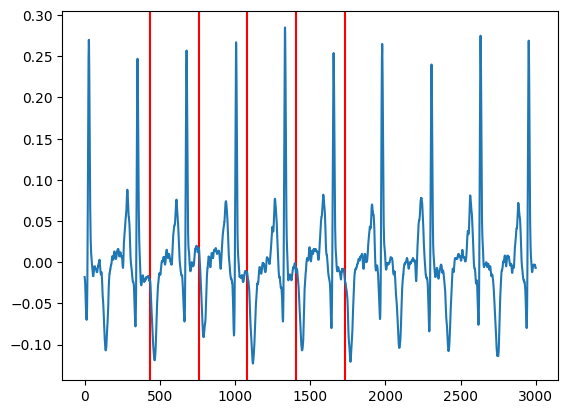

In [60]:
for r_p in r_peaks[:5]:
    plt.axvline(r_p, color=(1,0,0))
plt.plot(data_1[3000:,1])

In [62]:
x_stft.shape

torch.Size([8, 129, 21])

In [66]:
dummy_dwt = torch.randn(1, 8, 125, 120) # подставь свои размеры
dummy_stft = torch.randn(1, 8, 129, 21)
torch.onnx.export(loaded_model.cpu(), (dummy_dwt, dummy_stft), "ecg_model.onnx", 
                  input_names=['dwt', 'stft'], output_names=['logits'])

In [99]:
import scipy.io as sio
import torch
import numpy as np

# 1. Загружаем чекпоинт
checkpoint = torch.load('last_checkpoint.pth', map_location='cpu')

# 2. Достаем веса именно из нужного ключа
if 'model_state_dict' in checkpoint:
    sd = checkpoint['model_state_dict']
    print(f"Веса найдены в 'model_state_dict'. Количество записей: {len(sd)}")
else:
    print("Ключ 'model_state_dict' не найден! Доступные ключи:", checkpoint.keys())
    sd = {}

clean_dict = {}

# 3. Конвертация
for key, value in sd.items():
    if not hasattr(value, 'numpy'):
        continue
        
    new_key = key.replace('.', '_')
    new_key = new_key.replace('num_batches_tracked', 'nbt')
    new_key = new_key.replace('running_variance', 'var')
    new_key = new_key.replace('running_mean', 'mean')
    
    if len(new_key) > 62:
        new_key = new_key[:62]
    
    try:
        # Переводим в float32, чтобы MATLAB не ругался на формат
        val_np = value.detach().cpu().float().numpy()
        clean_dict[new_key] = val_np
    except Exception as e:
        print(f"Ошибка в слое {key}: {e}")

# 4. Сохранение
if len(clean_dict) > 0:
    sio.savemat('model_weights_fixed.mat', clean_dict, long_field_names=True)
    print(f"--- ПОБЕДА! ---")
    print(f"Успешно сохранено слоев: {len(clean_dict)}")
else:
    print("Что-то пошло не так, словарь пуст.")

Веса найдены в 'model_state_dict'. Количество записей: 55
--- ПОБЕДА! ---
Успешно сохранено слоев: 55


C:\Users\HundeRob0t\AppData\Local\Temp\ipykernel_16268\3447956730.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load('last_checkpoint.pth', map_loca

In [97]:
 print(checkpoint.keys())

dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'scheduler_state_dict', 'val_f1', 'val_loss'])
